# HELPER FUNCTIONS - 1

In [91]:
import numpy as np
import matplotlib.pyplot as plt

# Angle conversion
deg = np.pi / 180
TOL = 1e-12

# Polarization basis
H = np.array([1, 0], dtype=complex)
V = np.array([0, 1], dtype=complex)

def dagger(A):
    """Hermitian conjugate A†."""
    return np.conjugate(A.T)

def normalize(psi):
    """Normalize a Jones vector."""
    norm = np.linalg.norm(psi)

    if norm == 0:
        raise ValueError("Zero state cannot be normalized.")

    return psi / norm

def bloch_vector(psi):
    """
    Return the Bloch/Stokes vector (Sx, Sy, Sz)
    for a normalized polarization state |psi>.
    """

    psi = normalize(psi)

    a = psi[0]
    b = psi[1]

    Sx = 2 * np.real(np.conjugate(a) * b)
    Sy = 2 * np.imag(np.conjugate(a) * b)
    Sz = np.abs(a)**2 - np.abs(b)**2

    return np.array([Sx, Sy, Sz])

# INPUT STATE PREPARATION

In [92]:
def rotation(theta):
    """
    Polarization rotation matrix.

    theta: angle in radians
    """
    c = np.cos(theta)
    s = np.sin(theta)

    return np.array([
        [c, -s],
        [s,  c]
    ], dtype=complex)

def waveplate(theta, retardance):
    phase = np.array([
        [np.exp(-1j * retardance / 2), 0],
        [0, np.exp(+1j * retardance / 2)]
    ], dtype=complex)

    return rotation(theta) @ phase @ rotation(-theta)

def HWP(theta):
    """Half-wave plate."""
    return waveplate(theta, np.pi)


def QWP(theta):
    """Quarter-wave plate."""
    return waveplate(theta, np.pi / 2)

def PBS(output="H"):
    """
    Ideal PBS for the input state-preparation stage.

    output = "H" or "V"

    Returns the polarization state selected by the PBS.
    """
    output = output.upper()

    if output == "H":
        return H.copy()

    if output == "V":
        return V.copy()

    raise ValueError("PBS output must be 'H' or 'V'.")

def prepare_input_state(pbs_output, hwp_angle, qwp_angle):
    """
    PBS → HWP → QWP

    Angles are given in radians internally.
    """

    psi = PBS(pbs_output)

    psi = HWP(hwp_angle) @ psi
    psi = QWP(qwp_angle) @ psi

    return psi

# HELPER FUNCTIONS - 2

In [93]:
B_LR_from_HV = np.array([
    [1,  1j],
    [1, -1j]
], dtype=complex) / np.sqrt(2)

def HV_to_LR(psi):
    return B_LR_from_HV @ psi

def LR_to_HV(psi):
    return dagger(B_LR_from_HV) @ psi

def add_oam(psi_LR, n=0):
    """
    Append OAM mode |n> to a polarization state
    expressed in the L/R basis.

    Input:
        psi_LR = [L amplitude, R amplitude]

    Output:
        dictionary representing the joint state
    """

    state = {}

    if abs(psi_LR[0]) > 1e-12:
        state[("L", n)] = psi_LR[0]

    if abs(psi_LR[1]) > 1e-12:
        state[("R", n)] = psi_LR[1]

    return state

# Q-Plate

In [94]:
def qplate(state, alpha, delta):
    """
    Apply the q-plate transformation S(alpha, delta)
    to a dynamically represented polarization-OAM state.

    alpha : q-plate characteristic angle [radians]
    delta : retardance [radians]
    """

    new_state = {}

    c = np.cos(delta / 2)
    s = 1j * np.sin(delta / 2)

    for (pol, n), amplitude in state.items():

        if pol == "L":

            # Stationary component:
            new_state[("L", n)] = (
                new_state.get(("L", n), 0)
                + c * amplitude
            )

            # Shifted component:
            new_state[("R", n + 1)] = (
                new_state.get(("R", n + 1), 0)
                + s * np.exp(-2j * alpha) * amplitude
            )

        elif pol == "R":

            # Stationary component:
            new_state[("R", n)] = (
                new_state.get(("R", n), 0)
                + c * amplitude
            )

            # Shifted component:
            new_state[("L", n - 1)] = (
                new_state.get(("L", n - 1), 0)
                + s * np.exp(2j * alpha) * amplitude
            )

    # Remove numerical zeros
    new_state = {
        key: amplitude
        for key, amplitude in new_state.items()
        if abs(amplitude) > 1e-12
    }

    return new_state

# COIN OPERATION

In [95]:
def coin_matrix(zeta, theta, phi):
    return (
        B_LR_from_HV
        @ QWP(phi)
        @ HWP(theta)
        @ QWP(zeta)
        @ dagger(B_LR_from_HV)
    )

def apply_coin(state, zeta, theta, phi):
    """
    Apply the polarization-only coin operation
    to every occupied OAM mode.

    OAM n is unchanged.
    """

    C = coin_matrix(zeta, theta, phi)

    new_state = {}

    # Find all OAM modes currently present
    oam_modes = {
        n for (pol, n) in state.keys()
    }

    for n in oam_modes:

        # Current L/R amplitudes
        c_L = state.get(("L", n), 0.0)
        c_R = state.get(("R", n), 0.0)

        polarization = np.array([
            c_L,
            c_R
        ], dtype=complex)

        # Apply coin
        transformed = C @ polarization

        # Store resulting amplitudes
        if abs(transformed[0]) > TOL:
            new_state[("L", n)] = transformed[0]

        if abs(transformed[1]) > TOL:
            new_state[("R", n)] = transformed[1]

    return new_state

# PROJECTIONS

In [96]:
# --------------------------------------------------
# POLARIZATION PROJECTION
# --------------------------------------------------

def polarization_projection(state, psi_proj):
    """
    Project the polarization of the state onto psi_proj
    and return the remaining OAM state.

    psi_proj must be a normalized polarization ket in the L/R basis.
    """

    oam_state = {}

    oam_modes = {n for (pol, n) in state.keys()}

    for n in oam_modes:

        c_L = state.get(("L", n), 0.0)
        c_R = state.get(("R", n), 0.0)

        polarization = np.array(
            [c_L, c_R],
            dtype=complex
        )

        amplitude = np.vdot(psi_proj, polarization)

        if abs(amplitude) > TOL:
            oam_state[n] = amplitude

    return oam_state

def analyzer_projection_state(hwp_angle, qwp_angle, pbs_output="H"):
    """
    Return the polarization state projected by

        HWP -> QWP -> PBS

    expressed in the L/R basis.
    """

    pbs_output = pbs_output.upper()

    if pbs_output not in ("H", "V"):
        raise ValueError("pbs_output must be 'H' or 'V'.")

    U = QWP(qwp_angle) @ HWP(hwp_angle)

    selected = H if pbs_output == "H" else V

    # Back-propagate the selected PBS state
    psi_HV = dagger(U) @ selected

    # Convert to L/R
    psi_LR = HV_to_LR(psi_HV)

    return normalize(psi_LR)


def SLM_probability(oam_state, target_mode):
    """
    Probability of detecting the selected OAM mode.
    """
    amplitude = oam_state.get(target_mode, 0.0)

    return abs(amplitude)**2


# Setup

In [97]:
# ------------------------------------------------------------
# Fixed experimental parameters
# ------------------------------------------------------------

alpha_1 = 105 * deg
delta_1 = np.pi / 2

alpha_2 = 336 * deg
delta_2 = np.pi

hwp_out = 0 * deg
qwp_out = 0 * deg
pbs_out = "H"


# ------------------------------------------------------------
# Random reservoir coin
# ------------------------------------------------------------

coin_rng = np.random.default_rng()

zeta_c = coin_rng.uniform(0, np.pi)
theta_c = coin_rng.uniform(0, np.pi)
phi_c = coin_rng.uniform(0, np.pi)

print("Random coin:")
print(f"ζ = {zeta_c / deg:.3f}°")
print(f"θ = {theta_c / deg:.3f}°")
print(f"φ = {phi_c / deg:.3f}°")

# --------------------------------------------------
# RANDOM OUTPUT PROJECTION
# --------------------------------------------------

hwp_out = np.random.uniform(0, 2*np.pi)
qwp_out = np.random.uniform(0, 2*np.pi)
pbs_out = np.random.choice(["H", "V"])

random_projection = analyzer_projection_state(
    hwp_out,
    qwp_out,
    pbs_out
)

print("Random output analyzer:")
print(f"HWP = {hwp_out / deg:.3f}°")
print(f"QWP = {qwp_out / deg:.3f}°")
print(f"PBS = {pbs_out}")



# ------------------------------------------------------------
# Optical propagation
# ------------------------------------------------------------

def propagate_input(pbs_in, hwp_in, qwp_in):

    # Input preparation
    psi_HV = prepare_input_state(
        pbs_in,
        hwp_in,
        qwp_in
    )

    # Convert to L/R
    psi_LR = HV_to_LR(psi_HV)

    # Initial OAM
    state = add_oam(psi_LR, 0)

    # Reservoir
    state = qplate(
        state,
        alpha_1,
        delta_1
    )

    state = apply_coin(
        state,
        zeta_c,
        theta_c,
        phi_c
    )

    state = qplate(
        state,
        alpha_2,
        delta_2
    )

    # Output polarization projection
    oam_state = polarization_projection(
        state,
        random_projection
    )

    return psi_HV, oam_state

Random coin:
ζ = 15.827°
θ = 165.444°
φ = 59.939°
Random output analyzer:
HWP = 33.647°
QWP = 206.077°
PBS = V


# ELM

Feature modes: [-2, -1, 0, 1, 2]

QELM performance
----------------
MSE(Sx)  = 1.739140e-28
MSE(Sy)  = 4.775647e-31
MSE(Sz)  = 5.327927e-29
Mean MSE = 7.589027e-29


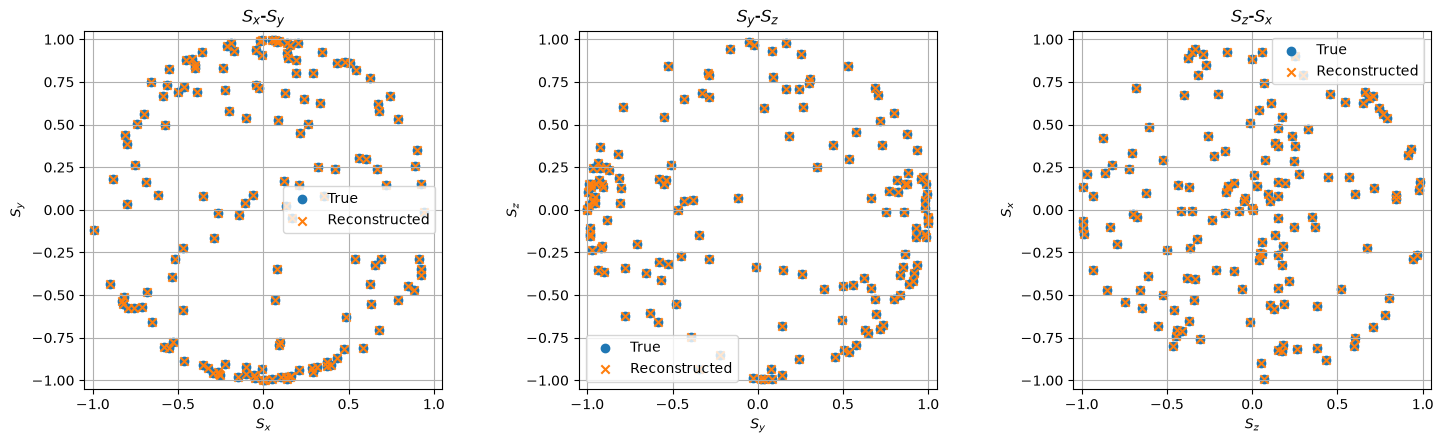

In [98]:
# ------------------------------------------------------------
# Generate raw data
# ------------------------------------------------------------

rng = np.random.default_rng()

n_samples = 300

raw_samples = []

for _ in range(n_samples):

    pbs_in = "H"
    hwp_in = rng.uniform(0, np.pi)
    qwp_in = rng.uniform(0, np.pi)

    psi, oam_state = propagate_input(
        pbs_in,
        hwp_in,
        qwp_in
    )

    raw_samples.append(
        (
            oam_state,
            bloch_vector(psi)
        )
    )


# ------------------------------------------------------------
# Determine the fixed feature ordering ONCE
# ------------------------------------------------------------

feature_modes = sorted({
    n
    for oam_state, _ in raw_samples
    for n in oam_state
})

print(f"Feature modes: {feature_modes}")

# ------------------------------------------------------------
# Convert OAM state -> fixed feature vector
# ------------------------------------------------------------

def features_from_oam(oam_state):
    """
    Use the feature ordering fixed during training.

    Missing OAM modes simply contribute zero.
    """

    return np.array([
        SLM_probability(oam_state, n)
        for n in feature_modes
    ])


# ------------------------------------------------------------
# Build X and Y
# ------------------------------------------------------------

X = np.array([
    features_from_oam(oam_state)
    for oam_state, _ in raw_samples
])

Y = np.array([
    target
    for _, target in raw_samples
])


# ------------------------------------------------------------
# Train / test split
# ------------------------------------------------------------

n_train = n_samples // 2

X_train = X[:n_train]
Y_train = Y[:n_train]

X_test = X[n_train:]
Y_test = Y[n_train:]


# ------------------------------------------------------------
# Train linear QELM readout
# ------------------------------------------------------------

W, _, _, _ = np.linalg.lstsq(
    X_train,
    Y_train,
    rcond=None
)


# ------------------------------------------------------------
# Test
# ------------------------------------------------------------

Y_pred = X_test @ W


# ------------------------------------------------------------
# MSE
# ------------------------------------------------------------

errors = Y_pred - Y_test

mse_x = np.mean(errors[:, 0] ** 2)
mse_y = np.mean(errors[:, 1] ** 2)
mse_z = np.mean(errors[:, 2] ** 2)

mse = np.mean(errors ** 2)

print("\nQELM performance")
print("----------------")
print(f"MSE(Sx)  = {mse_x:.6e}")
print(f"MSE(Sy)  = {mse_y:.6e}")
print(f"MSE(Sz)  = {mse_z:.6e}")
print(f"Mean MSE = {mse:.6e}")


# ------------------------------------------------------------
# Predict ANY new input state
# ------------------------------------------------------------

def predict_input(pbs_in, hwp_in, qwp_in):

    psi, oam_state = propagate_input(
        pbs_in,
        hwp_in,
        qwp_in
    )

    x = features_from_oam(oam_state)

    prediction = x @ W

    return prediction

# ------------------------------------------------------------
# True vs reconstructed Bloch vectors
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

planes = [
    (0, 1, r"$S_x$", r"$S_y$", r"$S_x$-$S_y$"),
    (1, 2, r"$S_y$", r"$S_z$", r"$S_y$-$S_z$"),
    (2, 0, r"$S_z$", r"$S_x$", r"$S_z$-$S_x$")
]

for ax, (i, j, xlabel, ylabel, title) in zip(axes, planes):

    ax.scatter(
        Y_test[:, i],
        Y_test[:, j],
        label="True"
    )

    ax.scatter(
        Y_pred[:, i],
        Y_pred[:, j],
        marker="x",
        label="Reconstructed"
    )

    ax.set(
        xlabel=xlabel,
        ylabel=ylabel,
        title=title,
        xlim=(-1.05, 1.05),
        ylim=(-1.05, 1.05)
    )

    ax.set_aspect("equal")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()